In [ ]:
 # In COLAB, install these and restart the runtime sessione to make scikit-plot work (roc curve and precision recall curve)
!pip install scikit-plot
!pip install scipy==1.11.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is inc

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Titanic Dataset

In [ ]:
df = pd.read_csv("data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Cleaning

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Removing useless variables

In [ ]:
column2drop = ['PassengerId', 'Name', 'Cabin']
df.drop(column2drop, axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


### Feature Engineering

In [ ]:
# number of people a passanger is travelling with
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
# if he/she is travelling alone or not
df['IsAlone'] = 1 # initialize to yes/1 is alone
df.loc[df.FamilySize > 1, 'IsAlone'] = 0 # update to no/0 if family size is greater than 1

Features SibSp and Parch are now redundant with respect to FamilySize.  

In [ ]:
column2drop = ['SibSp', 'Parch']
df.drop(column2drop, axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,A/5 21171,7.2500,S,2,0
1,1,1,female,38.0,PC 17599,71.2833,C,2,0
2,1,3,female,26.0,STON/O2. 3101282,7.9250,S,1,1
3,1,1,female,35.0,113803,53.1000,S,2,0
4,0,3,male,35.0,373450,8.0500,S,1,1


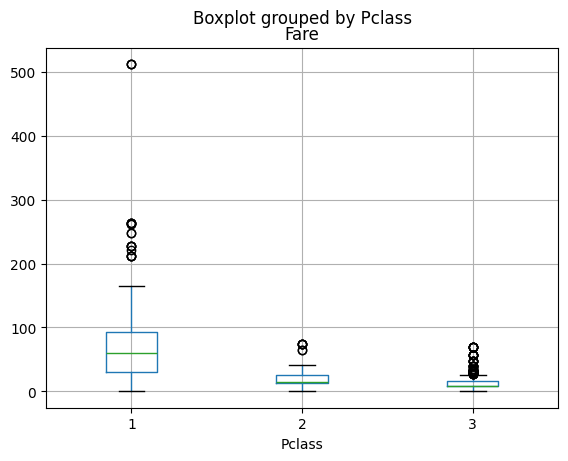

In [ ]:
# examining Fare feature
df.boxplot(['Fare'], by='Pclass', showfliers=True)
plt.show()

In [ ]:
dupl_df = df[df.duplicated('Ticket', keep=False)]
dupl_df

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone
3,1,1,female,35.0,113803,53.1000,S,2,0
7,0,3,male,2.0,349909,21.0750,S,5,0
8,1,3,female,27.0,347742,11.1333,S,3,0
9,1,2,female,14.0,237736,30.0708,C,2,0
10,1,3,female,4.0,PP 9549,16.7000,S,3,0
...,...,...,...,...,...,...,...,...,...
876,0,3,male,20.0,7534,9.8458,S,1,1
879,1,1,female,56.0,11767,83.1583,C,2,0
880,1,2,female,25.0,230433,26.0000,S,2,0
885,0,3,female,39.0,382652,29.1250,Q,6,0


In [ ]:
std = dupl_df[['Fare', 'Ticket']].groupby(['Ticket']).std()
std

,Fare
Ticket,
110152,0.0
110413,0.0
110465,0.0
111361,0.0
113505,0.0
...,...
SC/Paris 2123,0.0
STON/O2. 3101279,0.0
W./C. 6607,0.0


In [ ]:
std[std['Fare'] > 0]

,Fare
Ticket,
7534,0.444841


In [ ]:
df[df['Ticket'] == '7534']

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone
138,0,3,male,16.0,7534,9.2167,S,1,1
876,0,3,male,20.0,7534,9.8458,S,1,1


In [ ]:
df[df['Ticket'] == '110152']

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone
257,1,1,female,30.0,110152,86.5,S,1,1
504,1,1,female,16.0,110152,86.5,S,1,1
759,1,1,female,33.0,110152,86.5,S,1,1


It looks like Fare is cumulative with respect to various Tickets with the same identifier. Consequently we proceed in correcting the Fare of each passenger by dividing it with the number of Tickets with the same identifier.

In [ ]:
ticket_map = dict(df['Ticket'].value_counts()) # n. of occurrencies by ticket
df['NumTickets'] = df['Ticket'].map(ticket_map) # creates new column based on the value counts map

In [ ]:
df['Fare'] = df['Fare']/df['NumTickets']

In [ ]:
df[df['Ticket'] == '110152']

,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,FamilySize,IsAlone,NumTickets
257,1,1,female,30.0,110152,28.833333,S,1,1,3
504,1,1,female,16.0,110152,28.833333,S,1,1,3
759,1,1,female,33.0,110152,28.833333,S,1,1,3


The features NumTickets and Ticket helped in correcting Fare and we do not need theme any more.  

In [ ]:
column2drop = ['NumTickets', 'Ticket']
df.drop(column2drop, axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,7.2500,S,2,0
1,1,1,female,38.0,71.2833,C,2,0
2,1,3,female,26.0,7.9250,S,1,1
3,1,1,female,35.0,26.5500,S,2,0
4,0,3,male,35.0,8.0500,S,1,1


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# label encoding Sex feature
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
# one-hot encoding of categorical data
categorical_cols = ["Embarked"]
df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,7.2500,2,0,0,0,1
1,1,1,0,38.0,71.2833,2,0,1,0,0
2,1,3,0,26.0,7.9250,1,1,0,0,1
3,1,1,0,35.0,26.5500,2,0,0,0,1
4,0,3,1,35.0,8.0500,1,1,0,0,1


### Partitioning

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
attributes = [col for col in df.columns if col != 'Survived']
X = df[attributes].values
y = df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
dt = DecisionTreeClassifier()

In [ ]:
%%time
dt.fit(X_train, y_train)

CPU times: user 4.93 ms, sys: 0 ns, total: 4.93 ms
Wall time: 34.5 ms


DecisionTreeClassifier()

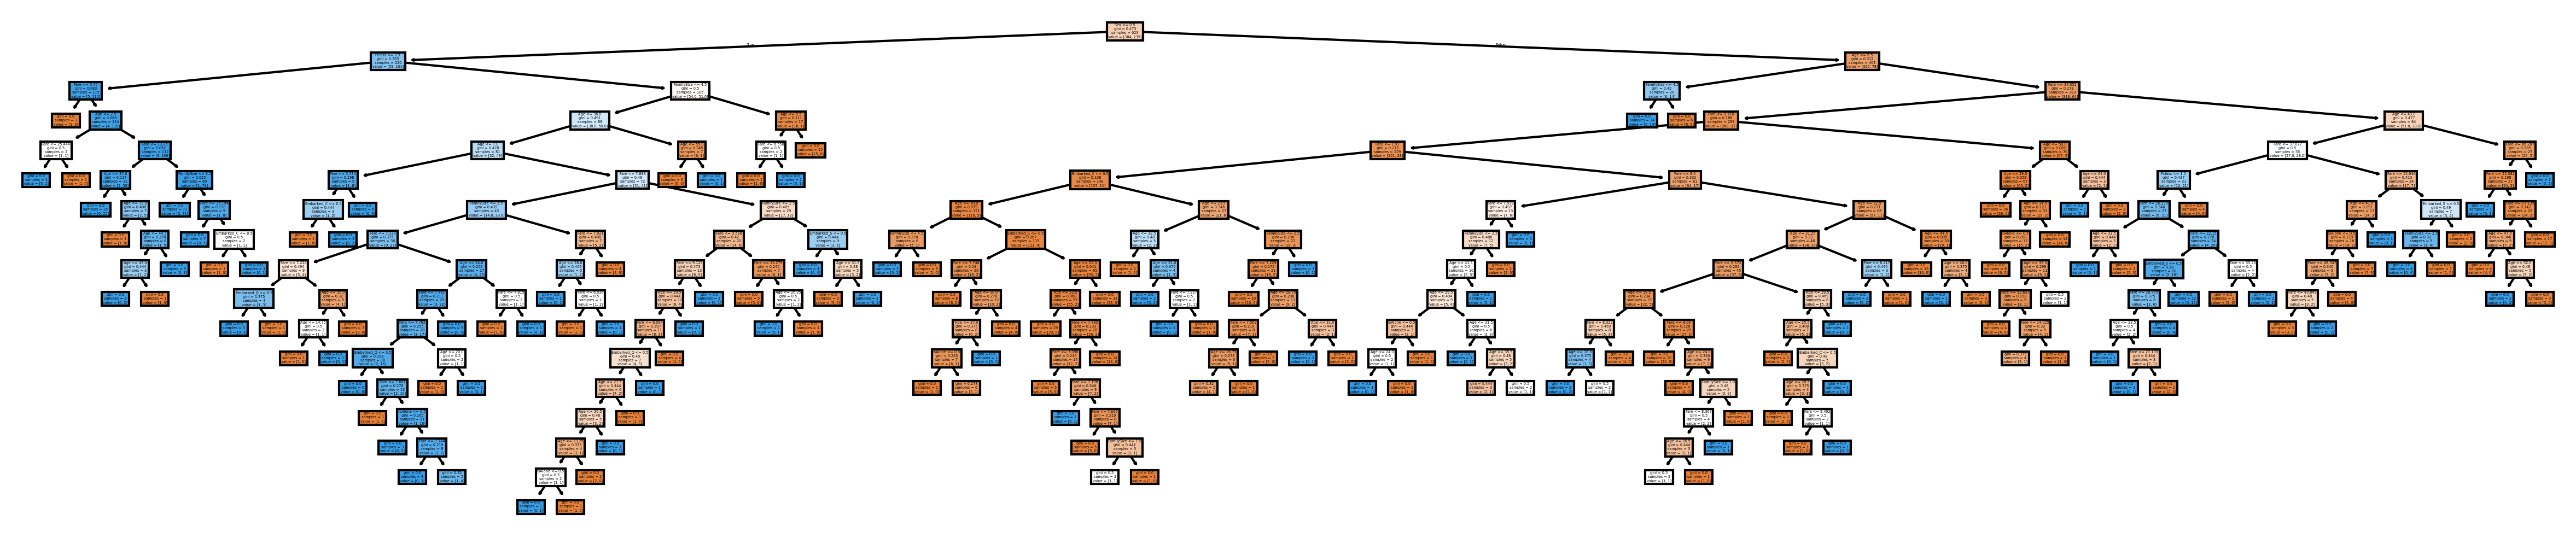

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True)
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [ ]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [ ]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.9839486356340289
Train F1-score [0.9871134 0.9787234]

Test Accuracy 0.7723880597014925
Test F1-score [0.8189911  0.69346734]


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       165
           1       0.72      0.67      0.69       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.76       268
weighted avg       0.77      0.77      0.77       268



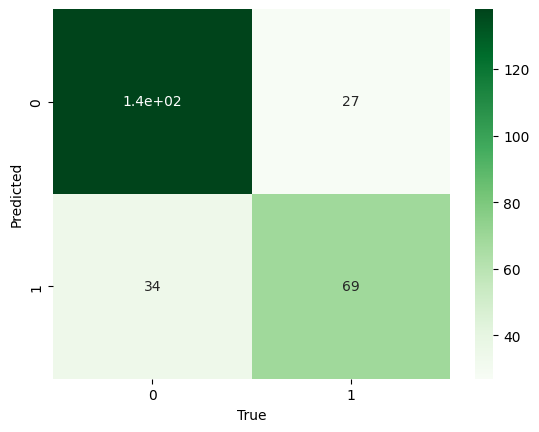

In [ ]:
cf = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf, annot=True, cmap="Greens")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

Feature Importance

In [ ]:
zipped = zip(attributes, dt.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Sex 0.2925058533225051
Fare 0.24031085140307284
Age 0.22378423564253816
Pclass 0.1012579139365421
FamilySize 0.0942865898857137
Embarked_C 0.016593318644224517
Embarked_S 0.015019973457942115
Embarked_Q 0.008811273014338488
IsAlone 0.007429990693123019


Let us discuss overfitting

In [ ]:
nodes = []
train_err = []
test_err = []

for max_depth in list(np.arange(1, 20)):
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_err.append(1 - accuracy_score(y_train, y_train_pred))
    test_err.append(1 - accuracy_score(y_test, y_test_pred))
    nodes.append(dt.tree_.node_count)

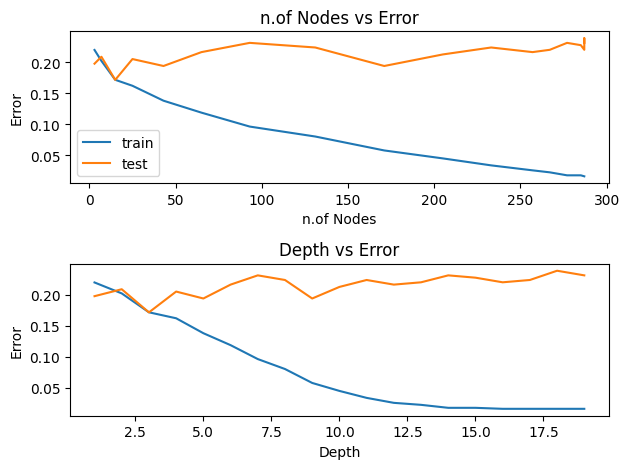

In [ ]:
fig, ax = plt.subplots(2,1)
ax[0].plot(nodes, train_err, label='train')
ax[0].plot(nodes, test_err, label='test')
ax[0].legend()

ax[0].set_xlabel("n.of Nodes")
ax[0].set_ylabel("Error")
ax[0].set_title("n.of Nodes vs Error")

ax[1].plot(list(np.arange(1, 20)), train_err, label='train')
ax[1].plot(list(np.arange(1, 20)), test_err, label='test')

ax[1].set_xlabel("Depth")
ax[1].set_ylabel("Error")
ax[1].set_title("Depth vs Error")

plt.tight_layout()
plt.show()

#### Decision Tree hyperparameters
max_depth : int, default=None <br>
    The maximum depth of the tree. If None, then nodes are expanded until
    all leaves are pure or until all leaves contain less than
    min_samples_split samples.

min_samples_split : int or float, default=2 <br>
    The minimum number of samples required to split an internal node:

    - If int, then consider `min_samples_split` as the minimum number.
    - If float, then `min_samples_split` is a fraction and
      `ceil(min_samples_split * n_samples)` are the minimum
      number of samples for each split.

min_samples_leaf : int or float, default=1 <br>
    The minimum number of samples required to be at a leaf node.
    A split point at any depth will only be considered if it leaves at
    least ``min_samples_leaf`` training samples in each of the left and
    right branches.  This may have the effect of smoothing the model,
    especially in regression.

    - If int, then consider `min_samples_leaf` as the minimum number.
    - If float, then `min_samples_leaf` is a fraction and
      `ceil(min_samples_leaf * n_samples)` are the minimum
      number of samples for each node.

In [ ]:
from sklearn.model_selection import cross_val_score

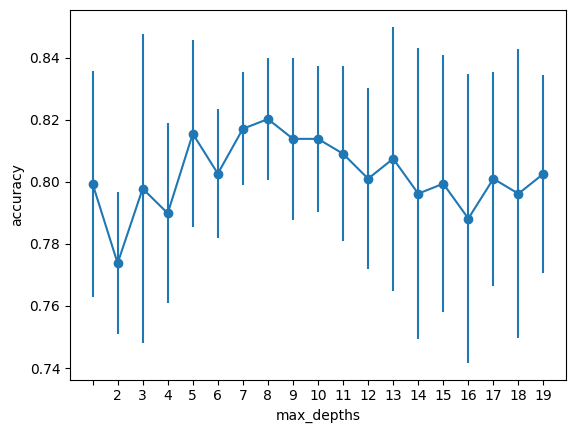

In [ ]:
max_depths = [None] + list(np.arange(2, 20))
avg_scores = list()
std_scores = list()

for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(max_depths)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(max_depths)), max_depths)
plt.xlabel("max_depths")
plt.ylabel("accuracy")
plt.show()

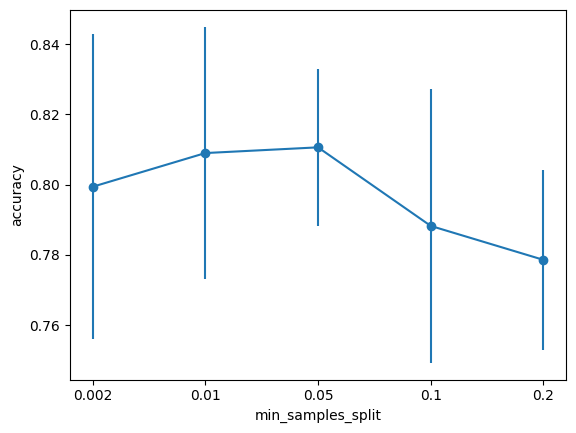

In [ ]:
min_samples_splits = [0.002, 0.01, 0.05, 0.1, 0.2]
avg_scores = list()
std_scores = list()

for min_samples_split in min_samples_splits:
    dt = DecisionTreeClassifier(min_samples_split=min_samples_split)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_splits)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_splits)), min_samples_splits)
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.show()

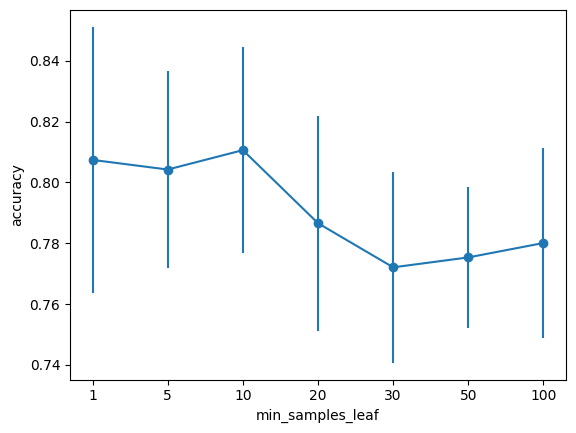

In [ ]:
min_samples_leafs = [1, 5, 10, 20, 30, 50, 100]
avg_scores = list()
std_scores = list()

for min_samples_leaf in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_leafs)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_leafs)), min_samples_leafs)
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.show()

### Randomized Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
%%time
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [2, 5, 10, 20, 30, 50, 100],
    'min_samples_leaf': [1, 5, 10, 20, 30, 50, 100],
    'criterion': ['gini', 'entropy']
}

clf = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=200,
    #verbose=2
)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_

CPU times: user 4 s, sys: 111 ms, total: 4.11 s
Wall time: 32.5 s


In [ ]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 9, 'criterion': 'entropy'} 0.8179638709677418


In [ ]:
y_test_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.7947761194029851


In [ ]:
clf.score(X_test, y_test)

0.7947761194029851

In [ ]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.9839486356340289
Train F1-score [0.9871134 0.9787234]

Test Accuracy 0.7947761194029851
Test F1-score [0.84057971 0.71204188]


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       165
           1       0.77      0.66      0.71       103

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



In [ ]:
results = pd.DataFrame(random_search.cv_results_)

In [ ]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,params,split0_test_score,...,split43_test_score,split44_test_score,split45_test_score,split46_test_score,split47_test_score,split48_test_score,split49_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003738,0.000817,0.001546,0.000144,30,10,13,gini,"{'min_samples_split': 30, 'min_samples_leaf': ...",0.792,...,0.806452,0.750000,0.856,0.784,0.800,0.782258,0.862903,0.806077,0.032492,20
1,0.004376,0.002172,0.001853,0.000807,20,5,7,entropy,"{'min_samples_split': 20, 'min_samples_leaf': ...",0.832,...,0.814516,0.766129,0.824,0.776,0.816,0.758065,0.854839,0.810107,0.037578,7
2,0.003763,0.001598,0.001702,0.000608,2,20,11,entropy,"{'min_samples_split': 2, 'min_samples_leaf': 2...",0.848,...,0.782258,0.806452,0.848,0.776,0.752,0.758065,0.838710,0.791969,0.033434,65
3,0.003115,0.000884,0.001445,0.000405,2,5,5,entropy,"{'min_samples_split': 2, 'min_samples_leaf': 5...",0.832,...,0.814516,0.790323,0.808,0.768,0.776,0.806452,0.838710,0.817495,0.035127,3
4,0.003737,0.000771,0.001606,0.000534,10,1,9,entropy,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.840,...,0.782258,0.830645,0.824,0.760,0.816,0.717742,0.830645,0.807523,0.029780,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.002993,0.000825,0.001544,0.000402,50,30,15,entropy,"{'min_samples_split': 50, 'min_samples_leaf': ...",0.800,...,0.790323,0.766129,0.816,0.776,0.752,0.750000,0.806452,0.783970,0.029386,97
196,0.004358,0.001706,0.001933,0.001002,5,1,10,gini,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.816,...,0.774194,0.798387,0.816,0.760,0.800,0.774194,0.838710,0.794850,0.033676,52
197,0.002706,0.000913,0.001419,0.000311,50,50,6,entropy,"{'min_samples_split': 50, 'min_samples_leaf': ...",0.752,...,0.798387,0.782258,0.816,0.776,0.752,0.782258,0.798387,0.775634,0.025992,155
198,0.002839,0.000436,0.001516,0.000241,100,20,11,entropy,"{'min_samples_split': 100, 'min_samples_leaf':...",0.760,...,0.766129,0.790323,0.816,0.752,0.760,0.782258,0.798387,0.771124,0.027395,196


<Axes: xlabel='param_max_depth', ylabel='mean_test_score'>

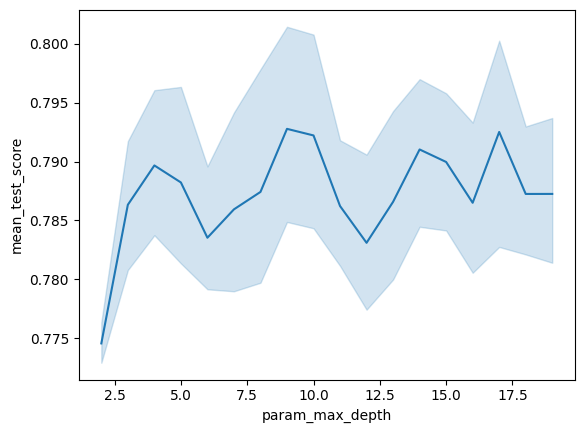

In [ ]:
sns.lineplot(data=results, x="param_max_depth", y="mean_test_score")

<Axes: xlabel='param_min_samples_leaf', ylabel='mean_test_score'>

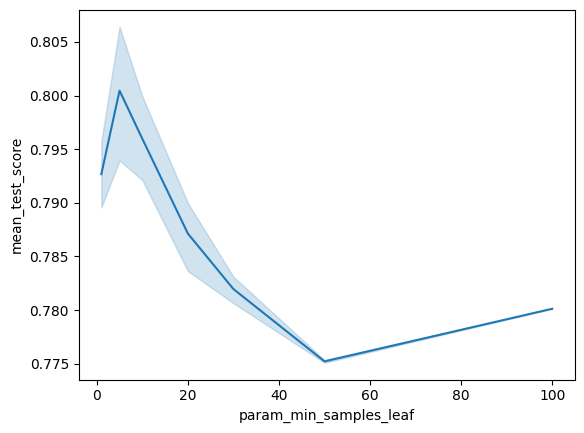

In [ ]:
sns.lineplot(data=results, x="param_min_samples_leaf", y="mean_test_score")

In [ ]:
zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Sex 0.3339787805926305
Fare 0.20037040829084243
Age 0.18961122607900174
Pclass 0.14794511423320023
FamilySize 0.09909533183992378
Embarked_C 0.01212762680382627
IsAlone 0.010581617605101496
Embarked_S 0.006289894555473573
Embarked_Q 0.0


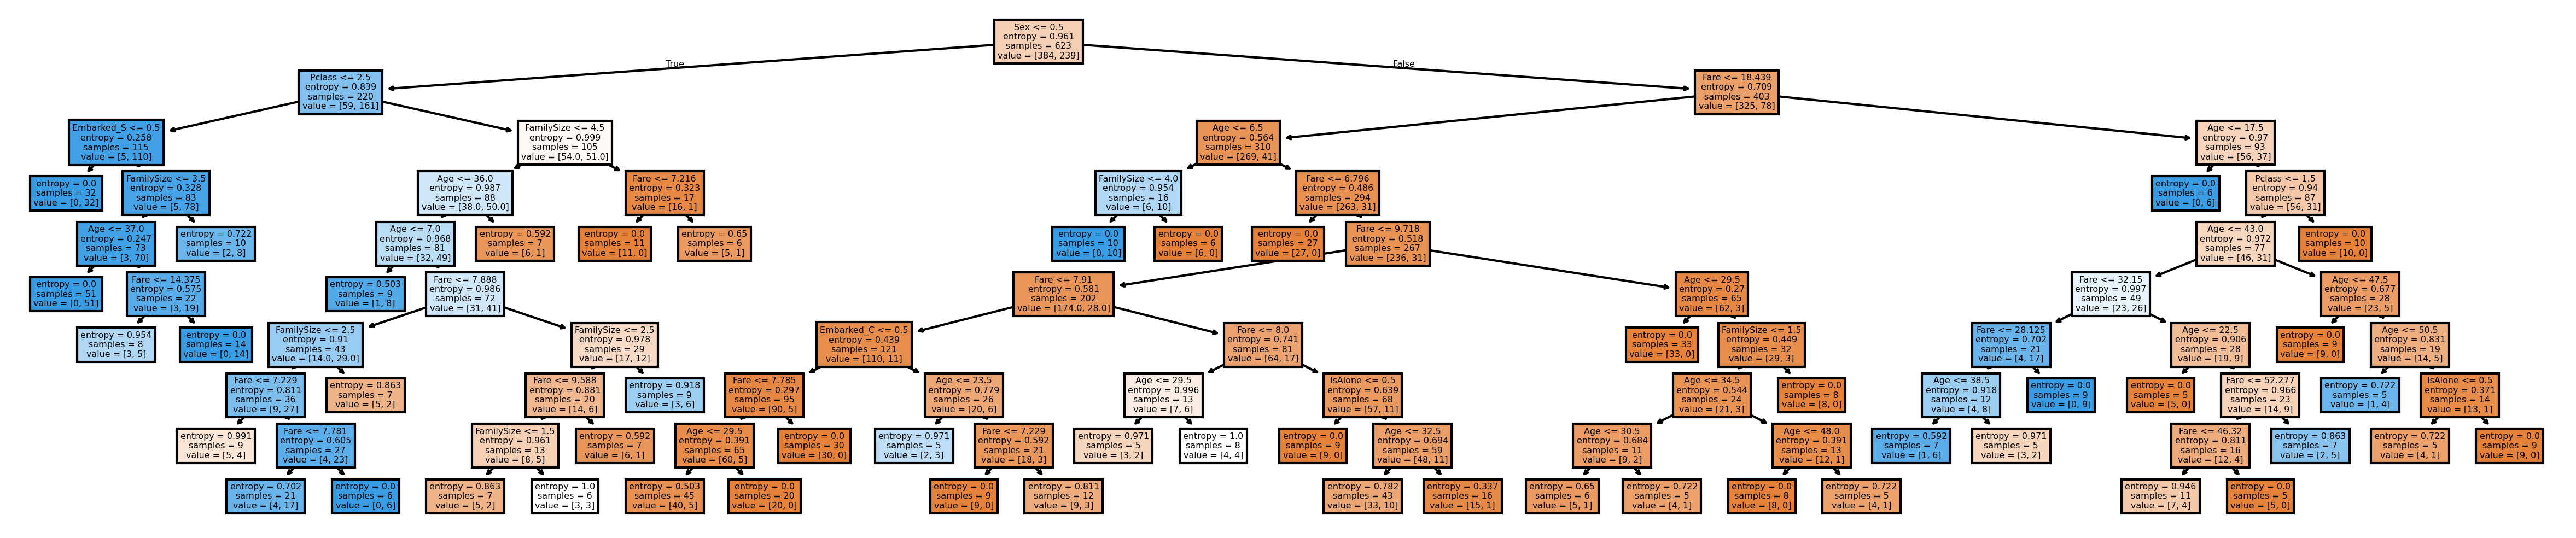

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True)
plt.show()

#### ccp_alphas
Minimal cost complexity pruning recursively finds the node with the “weakest link”. The weakest link is characterized by an effective alpha, where the nodes with the smallest effective alpha are pruned first. <br>
Sklearn decision tree offers a function that returns the effective alphas and the corresponding total leaf impurities at each step of the pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.

In [ ]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
for alpha, imp in zip(ccp_alphas, impurities):
    print(alpha, imp)

0.0 0.34430166502607223
2.3511697756857866e-05 0.3443251767238291
0.0001439870061487776 0.3444691637299779
0.0007291041435489101 0.3451982678735268
0.001534095802828284 0.3482664594791834
0.0015859272442057329 0.34985238672338914
0.002115757628164735 0.3519681443515539
0.002546924191598148 0.354515068543152
0.0025483340265416484 0.35706340256969366
0.002549341881226585 0.35961274445092023
0.0030533763119791474 0.3626661207628994
0.0032473315992042357 0.36591345236210365
0.00397271672536062 0.3698861690874643
0.003988041826140758 0.37387421091360507
0.004138341317398205 0.3780125522310033
0.004317481310945882 0.38233003354194917
0.004469031414121284 0.38679906495607047
0.00454098236184735 0.3913400473179178
0.004788466207210268 0.3961285135251281
0.005091248858660866 0.40631101124244984
0.00509660587730797 0.4114076171197578
0.005698694310845055 0.434202394363138
0.005902938142331116 0.4401053325054691
0.005945984720778667 0.4638892713885838
0.005990766562510949 0.4698800379510948
0.006

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

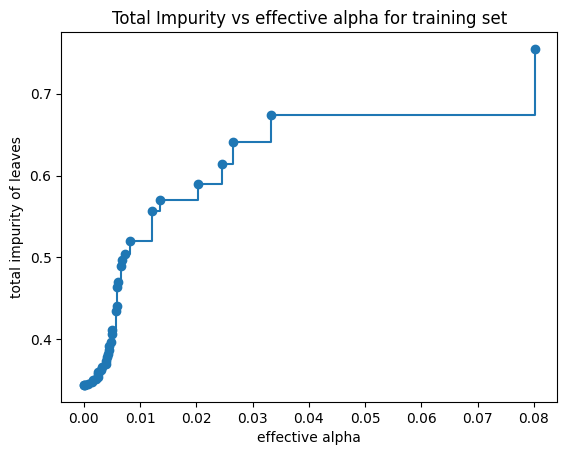

In [ ]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [ ]:
random_search.best_params_

{'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_depth': 9,
 'criterion': 'entropy'}

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    clf.fit(X_train, y_train)
    clfs.append(clf)

print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.20581849199058122


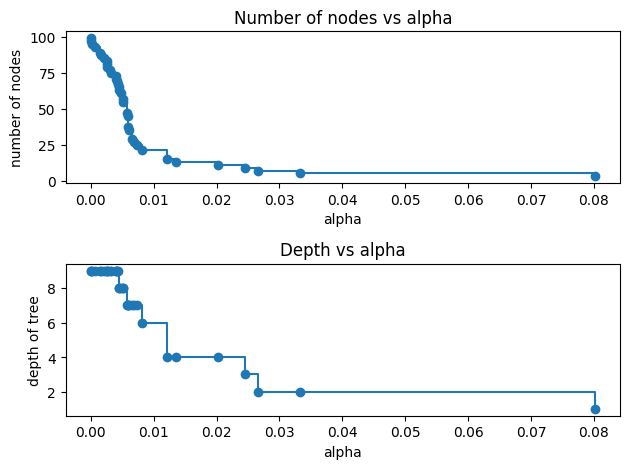

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

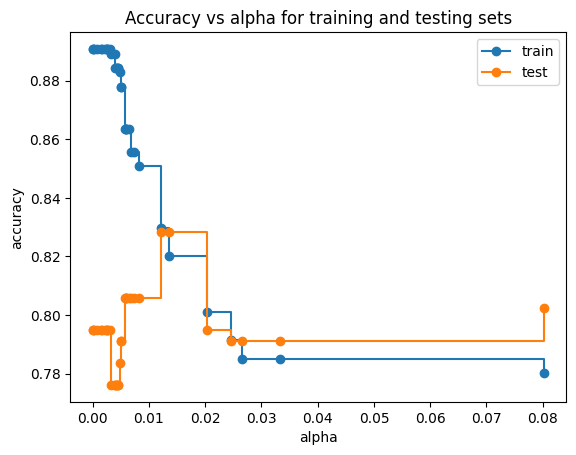

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
dtp = DecisionTreeClassifier()
dtp.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_test_pred = dtp.predict(X_test)

In [ ]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.9839486356340289
Train F1-score [0.9871134 0.9787234]

Test Accuracy 0.7723880597014925
Test F1-score [0.8189911  0.69346734]


In [ ]:
y_test_pred = dtp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.7723880597014925


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       165
           1       0.72      0.67      0.69       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.76       268
weighted avg       0.77      0.77      0.77       268



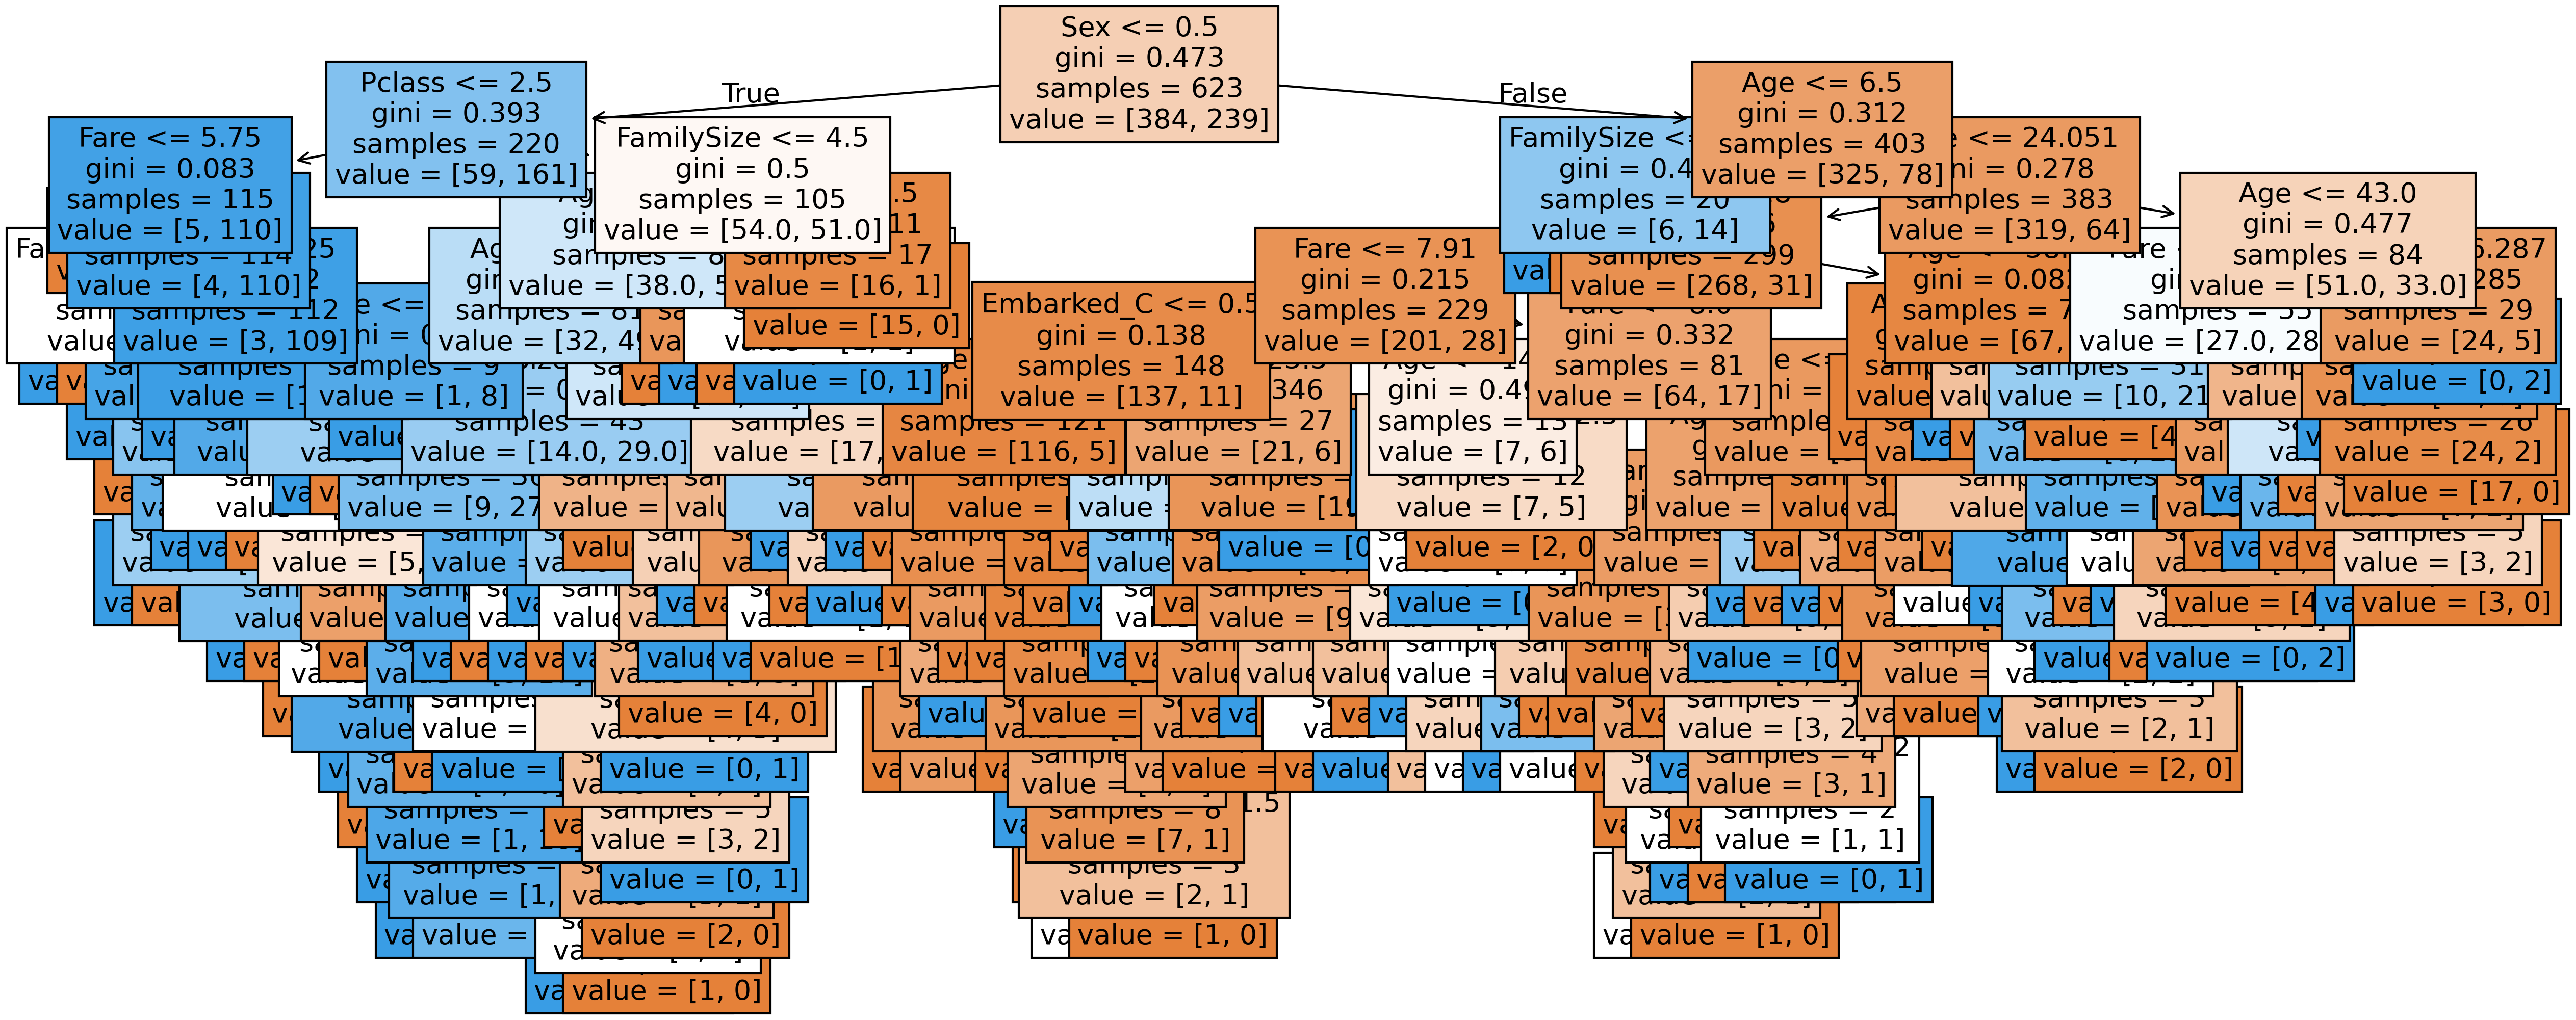

In [ ]:

plt.figure(figsize=(20, 8), dpi=300)
plot_tree(dtp, feature_names=attributes, filled=True, fontsize=13)
plt.show()

### ROC Curves

In [ ]:
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall

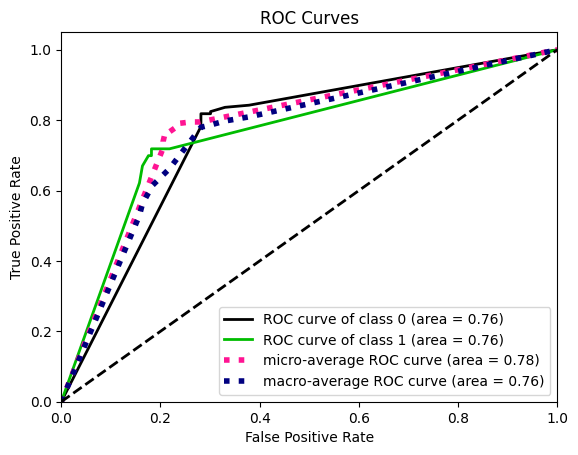

In [ ]:
plot_roc(y_test, dtp.predict_proba(X_test))
plt.show()

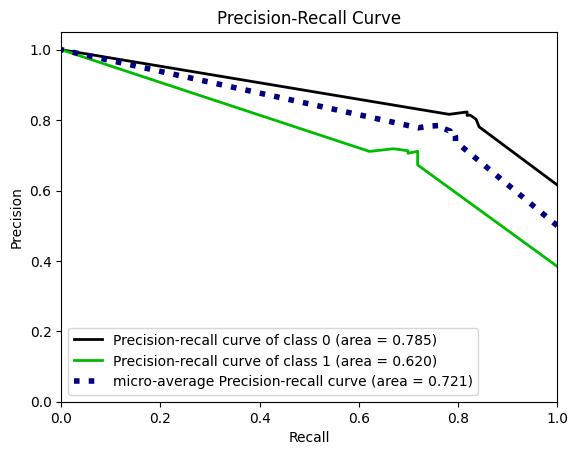

In [ ]:
plot_precision_recall(y_test, dtp.predict_proba(X_test))
plt.show()

### Pruning Utils
In scikit-learn's decision trees, it can sometimes occur that a node split creates branches where all subsequent splits lead to the same predicted label as the node itself. In such cases, these branches do not contribute additional information to the predictions. Tree pruning functions are designed to simplify the tree by removing such redundant branches, keeping only the root node of the branch. This process reduces the complexity of the tree and is particularly useful for improving interpretability and visualization.

In [ ]:
from sklearn.tree._tree import TREE_LEAF

In [ ]:
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)


def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))


def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [ ]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=5, min_samples_leaf=5, random_state=94)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=5,
                       min_samples_split=5, random_state=94)

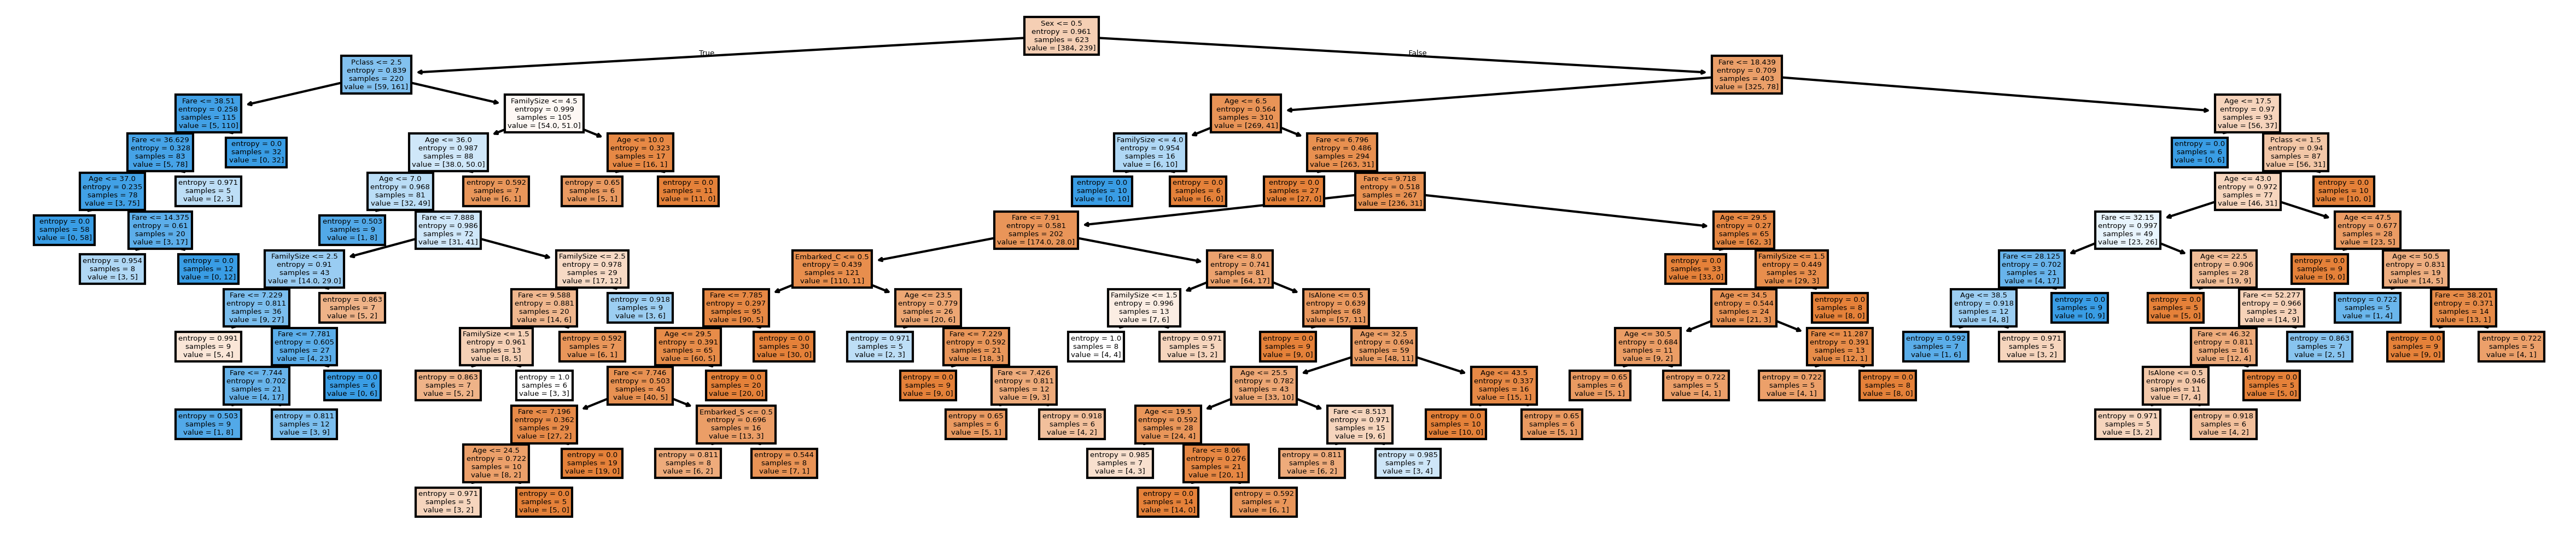

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True)
plt.show()

In [ ]:
prune_duplicate_leaves(dt)

In [ ]:
# let us visualise it again after pruning

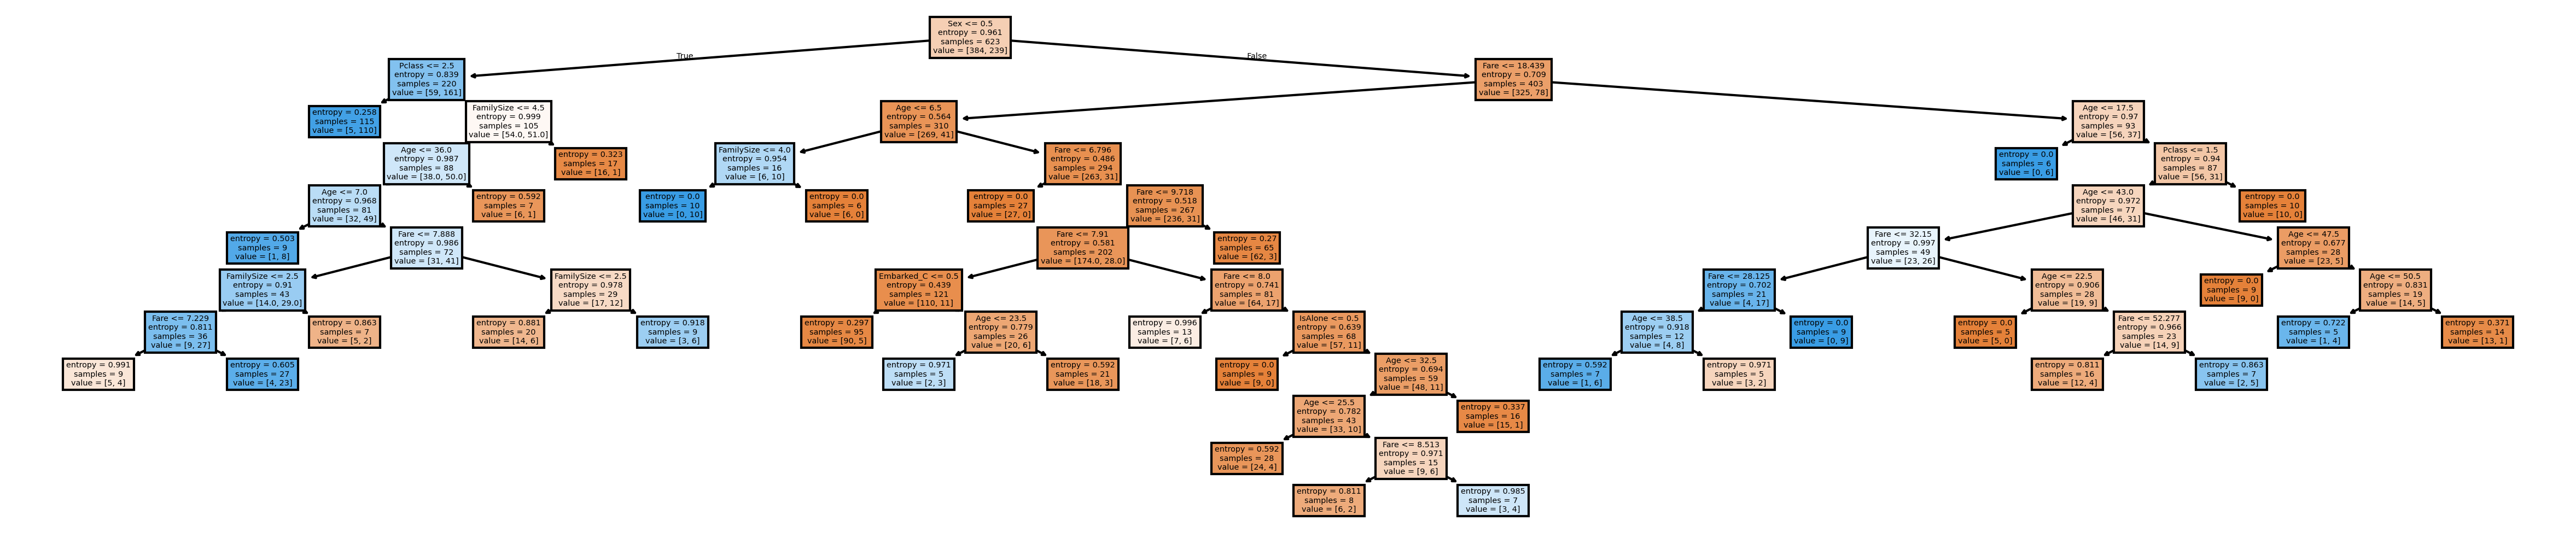

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True)
plt.show()

### RuleTree

RuleTree is a sklearn-inspired Decision Tree library developed internally in the KDD lab. It is capable of directly handling the "children with same classes" problem directly in its parameters.

Feel free to explore RuleTrees: using scikit learn implementation is mandatory, while using RuleTree is an additional exploration you can do

For code examples on classification and code implementation, check:  

https://github.com/fismimosa/RuleTree

https://github.com/fismimosa/RuleTree/blob/main/Examples/RuleTreeClassifier_example.ipynb


The correct import is **RuleTree.tree.RuleTreeClassifier**, not ruletree.tree.RuleTreeClassifier as in the repository, which still need to be updated

In [ ]:
#!pip install RuleTree

In [ ]:
#Initialize the RuleTreeClassifier and train it on your dataset


from RuleTree.tree.RuleTreeClassifier import RuleTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
X_train.shape, attributes

((623, 9),
 ['Pclass',
  'Sex',
  'Age',
  'Fare',
  'FamilySize',
  'IsAlone',
  'Embarked_C',
  'Embarked_Q',
  'Embarked_S'])

In [ ]:
rtc = RuleTreeClassifier(
    max_depth=3,
    criterion='gini',
    prune_useless_leaves=True, ##prune_useless_leaves performing the pruning internally for you without the need to access external functions
    random_state=42
)


IMPORTANT DETAIL: for training, both X_train and y_train should be numpy objects, not pandas series

In [ ]:
# Fit the RuleTreeClassifier to the training data
rtc.fit(X_train, np.array(y_train))

RuleTreeClassifier(base_stumps=[(1.0,
                                 DecisionTreeStumpClassifier(ccp_alpha=0.0,
                                                             class_weight=None,
                                                             criterion='gini',
                                                             max_depth=1,
                                                             max_features=None,
                                                             min_impurity_decrease=0.0,
                                                             min_samples_leaf=1,
                                                             min_samples_split=2,
                                                             min_weight_fraction_leaf=0.0,
                                                             monotonic_cst=None,
                                                             random_state=42,
                                                             splitter='best'))],
                   max_depth=3, prune_useless_leaves=True, random_state=42)

In [ ]:
# Extract the rules as a dictionary using feature names
rules = rtc.get_rules(columns_names=attributes)

In [ ]:
# Print textual rules of trained tree
rtc.print_rules(rules, columns_names=attributes)

|--- Sex <= 0.5	623
|   |--- Pclass <= 2.5	220
|   |   |--- Fare <= 5.75	115
|   |   |    output: 0
|   |   |--- Fare > 5.75
|   |   |    output: 1
|   |--- Pclass > 2.5
|   |   |--- FamilySize <= 4.5	105
|   |   |    output: 1
|   |   |--- FamilySize > 4.5
|   |   |    output: 0
|--- Sex > 0.5
|   |--- Age <= 6.5	403
|   |   |--- FamilySize <= 4.5	20
|   |   |    output: 1
|   |   |--- FamilySize > 4.5
|   |   |    output: 0
|   |--- Age > 6.5
|   |    output: 0


In [ ]:
y_pred = rtc.predict(X_test)

In [ ]:
print('Accuracy result\n', accuracy_score(y_test, y_pred))

Accuracy result
 0.8283582089552238


In [ ]:
# Obtain global feature importances similar to sklearn feature_importances_ of a trained Tree
feture_importances = rtc.compute_feature_importances()
for attr, imp in zip(attributes, feture_importances):
  print(attr, imp)

Pclass 0.17992977235110494
Sex 0.6098058869982659
Age 0.07982962656091805
Fare 0.01365006097271372
FamilySize 0.11678465311699747
IsAlone 0.0
Embarked_C 0.0
Embarked_Q 0.0
Embarked_S 0.0


In [ ]:
# Get local feature importances similar to https://github.com/andosa/treeinterpreter implementation
# Prediction is the sum of bias and feature contributions
prediction, bias, contributions = rtc.local_interpretation(X_test, joint_contribution= True)

In [ ]:
prediction[0], bias[0], contributions[0]

(array([0.83289817, 0.16710183]),
 array([0.61637239, 0.38362761]),
 {(1,): array([ 0.19007922, -0.19007922]),
  (1, 2): array([ 0.02644656, -0.02644656])})

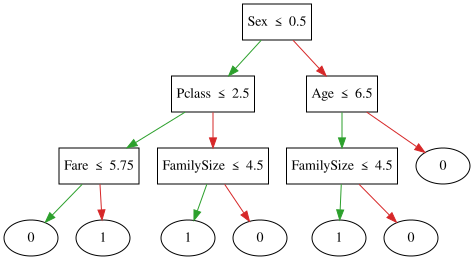

In [ ]:
rtc.export_graphviz(columns_names = attributes)

In [ ]:
rtc.export_graphviz(columns_names = attributes, filename = 'data/rtc_plot_tree') #adding filename will save a pdf of the plot

In [170]:
#directly obtain information on the nodes in the tree

rtc.root.node_to_dict()

{'node_id': 'R',
 'is_leaf': False,
 'prediction': 0,
 'prediction_probability': [0.6163723916532905, 0.38362760834670945],
 'prediction_classes_': [0, 1],
 'features': 9,
 'left_node': 'Rl',
 'right_node': 'Rr',
 'feature_idx': 1,
 'threshold': 0.5,
 'is_categorical': None,
 'samples': 623,
 'feature_name': 'X_1',
 'textual_rule': 'X_1 <= 0.5\t623',
 'blob_rule': 'X_1 <= 0.5',
 'graphviz_rule': {'label': 'X_1 ≤ 0.5'},
 'not_textual_rule': 'X_1 > 0.5',
 'not_blob_rule': 'X_1 > 0.5',
 'not_graphviz_rule': {'label': 'X_1 > 0.5'},
 'stump_type': 'RuleTree.stumps.classification.DecisionTreeStumpClassifier',
 'impurity': 0.4729149329217863,
 'args': {'is_oblique': False,
  'is_pivotal': False,
  'unique_val_enum': None,
  'coefficients': None,
  'max_depth': 1,
  'criterion': 'gini',
  'splitter': 'best',
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'min_weight_fraction_leaf': 0.0,
  'max_features': None,
  'random_state': 42,
  'min_impurity_decrease': 0.0,
  'class_weight': None,


In [171]:
#navigate the tree from the root with .node_l and .node_r
rtc.root.node_l.node_to_dict()

{'node_id': 'Rl',
 'is_leaf': False,
 'prediction': 1,
 'prediction_probability': [0.2681818181818182, 0.7318181818181818],
 'prediction_classes_': [0, 1],
 'features': 9,
 'left_node': 'Rll',
 'right_node': 'Rlr',
 'feature_idx': 0,
 'threshold': 2.5,
 'is_categorical': None,
 'samples': 220,
 'feature_name': 'X_0',
 'textual_rule': 'X_0 <= 2.5\t220',
 'blob_rule': 'X_0 <= 2.5',
 'graphviz_rule': {'label': 'X_0 ≤ 2.5'},
 'not_textual_rule': 'X_0 > 2.5',
 'not_blob_rule': 'X_0 > 2.5',
 'not_graphviz_rule': {'label': 'X_0 > 2.5'},
 'stump_type': 'RuleTree.stumps.classification.DecisionTreeStumpClassifier',
 'impurity': 0.3925206611570248,
 'args': {'is_oblique': False,
  'is_pivotal': False,
  'unique_val_enum': None,
  'coefficients': None,
  'max_depth': 1,
  'criterion': 'gini',
  'splitter': 'best',
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'min_weight_fraction_leaf': 0.0,
  'max_features': None,
  'random_state': 42,
  'min_impurity_decrease': 0.0,
  'class_weight': None